In [1]:
# ==========================================
# SENTIMENT ANALYSIS / NLP TEXT CLASSIFICATION
# Author: Himanshu Kumar Gupta
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset

df = pd.read_csv("Combined Data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Display first 5 records

df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [4]:
# Dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 53043
Number of columns: 3


In [5]:
# Display column names

print("Column names:")
print(df.columns.tolist())

Column names:
['Unnamed: 0', 'statement', 'status']


In [6]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [7]:
# Missing values

print("Missing values:")
print(df.isnull().sum())

Missing values:
Unnamed: 0      0
statement     362
status          0
dtype: int64


In [8]:
# Remove the unnecessary index column

df = df.drop(columns=["Unnamed: 0"])

# Remove rows with missing statements

df = df.dropna(subset=["statement"])

# Reset the index

df = df.reset_index(drop=True)

print("Dataset cleaned successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset cleaned successfully!
Rows: 52681
Columns: 2


In [9]:
# Check the distribution of status categories

status_counts = df["status"].value_counts()

print(status_counts)

status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


In [10]:
# Calculate percentage distribution

status_percentage = df["status"].value_counts(normalize=True) * 100

print(status_percentage.round(2))

status
Normal                  31.02
Depression              29.24
Suicidal                20.22
Anxiety                  7.29
Bipolar                  5.27
Stress                   4.91
Personality disorder     2.04
Name: proportion, dtype: float64


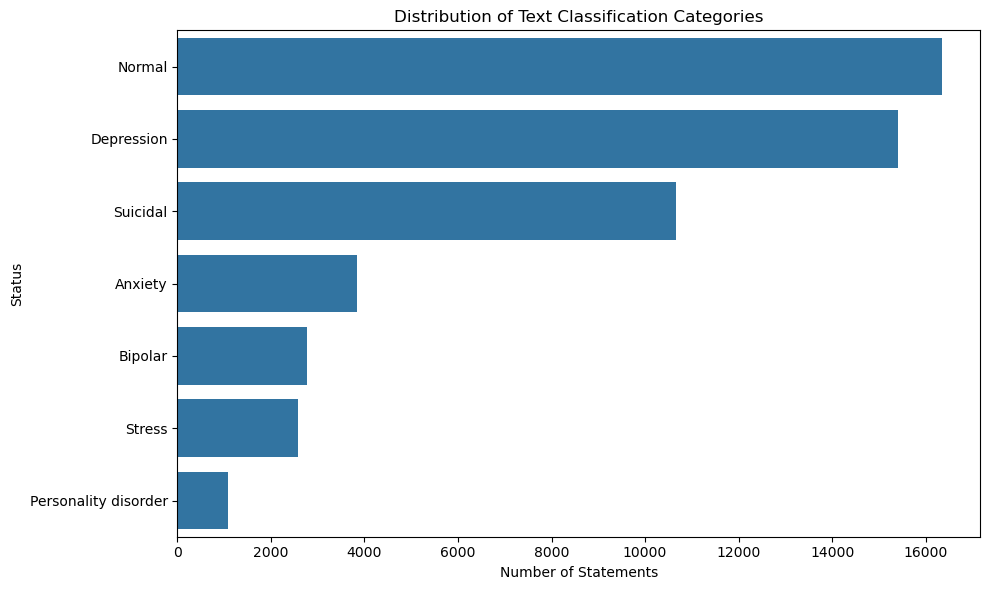

In [11]:
# Visualize status distribution

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="status",
    order=df["status"].value_counts().index
)

plt.title("Distribution of Text Classification Categories")
plt.xlabel("Number of Statements")
plt.ylabel("Status")

plt.tight_layout()
plt.show()

In [12]:
# Create a summary of status distribution

status_summary = pd.DataFrame({
    "Count": df["status"].value_counts(),
    "Percentage": df["status"].value_counts(normalize=True).mul(100).round(2)
})

status_summary

,Count,Percentage
status,,
Normal,16343,31.02
Depression,15404,29.24
Suicidal,10652,20.22
Anxiety,3841,7.29
Bipolar,2777,5.27
Stress,2587,4.91
Personality disorder,1077,2.04


In [13]:
# Sort categories alphabetically for a clean summary

status_summary = status_summary.sort_index()

status_summary

,Count,Percentage
status,,
Anxiety,3841,7.29
Bipolar,2777,5.27
Depression,15404,29.24
Normal,16343,31.02
Personality disorder,1077,2.04
Stress,2587,4.91
Suicidal,10652,20.22


In [14]:
# Calculate text length features

df["character_count"] = df["statement"].str.len()

df["word_count"] = df["statement"].str.split().str.len()

df["sentence_count"] = df["statement"].str.count(r"[.!?]") + 1

df[["statement", "character_count", "word_count", "sentence_count"]].head()

,statement,character_count,word_count,sentence_count
0,oh my gosh,10,3,1
1,"trouble sleeping, confused mind, restless hear...",64,10,2
2,"All wrong, back off dear, forward doubt. Stay ...",78,14,2
3,I've shifted my focus to something else but I'...,61,11,1
4,"I'm restless and restless, it's been a month n...",72,14,3


In [15]:
# Summary statistics of text features

df[["character_count", "word_count", "sentence_count"]].describe()

,character_count,word_count,sentence_count
count,52681.000000,52681.000000,52681.000000
mean,578.713863,113.158729,7.743152
std,846.269078,163.735305,12.376316
min,2.000000,1.000000,1.000000
25%,80.000000,15.000000,1.000000
50%,317.000000,62.000000,4.000000
75%,752.000000,148.000000,10.000000
max,32759.000000,6300.000000,1261.000000


In [16]:
# Average text length by status

text_length_by_status = df.groupby("status")[
    ["character_count", "word_count", "sentence_count"]
].mean().round(2)

text_length_by_status

,character_count,word_count,sentence_count
status,,,
Anxiety,764.68,143.84,10.31
Bipolar,946.07,176.20,13.08
Depression,844.03,168.02,9.54
Normal,90.24,17.25,2.27
Personality disorder,956.73,179.35,12.52
Stress,613.55,114.59,8.25
Suicidal,734.97,146.44,10.62


In [17]:
# NLP preprocessing libraries

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("NLP libraries imported successfully!")

NLP libraries imported successfully!


In [18]:
# Download required NLTK resources

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("NLTK resources downloaded successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...


NLTK resources downloaded successfully!


In [19]:
# Create text preprocessing function

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    # Tokenize words
    words = text.split()
    
    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)

In [20]:
# Apply text preprocessing

df["cleaned_statement"] = df["statement"].apply(clean_text)

df[["statement", "cleaned_statement"]].head(10)

,statement,cleaned_statement
0,oh my gosh,oh gosh
1,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",wrong back dear forward doubt stay restless re...
3,I've shifted my focus to something else but I'...,ive shifted focus something else im still worried
4,"I'm restless and restless, it's been a month n...",im restless restless month boy mean
5,"every break, you must be nervous, like somethi...",every break must nervous like something wrong ...
6,"I feel scared, anxious, what can I do? And may...",feel scared anxious may family u protected
7,Have you ever felt nervous but didn't know why?,ever felt nervous didnt know
8,"I haven't slept well for 2 days, it's like I'm...",havent slept well day like im restless huh
9,"I'm really worried, I want to cry.",im really worried want cry


In [21]:
df[["statement", "cleaned_statement"]].head(10)

,statement,cleaned_statement
0,oh my gosh,oh gosh
1,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",wrong back dear forward doubt stay restless re...
3,I've shifted my focus to something else but I'...,ive shifted focus something else im still worried
4,"I'm restless and restless, it's been a month n...",im restless restless month boy mean
5,"every break, you must be nervous, like somethi...",every break must nervous like something wrong ...
6,"I feel scared, anxious, what can I do? And may...",feel scared anxious may family u protected
7,Have you ever felt nervous but didn't know why?,ever felt nervous didnt know
8,"I haven't slept well for 2 days, it's like I'm...",havent slept well day like im restless huh
9,"I'm really worried, I want to cry.",im really worried want cry


In [22]:
# Combine all cleaned statements into one text

all_words = " ".join(df["cleaned_statement"])

# Split into individual words

words = all_words.split()

# Count word frequency

word_frequency = pd.Series(words).value_counts()

# Display the 20 most frequent words

word_frequency.head(20)

like      38566
feel      35627
want      28716
know      24435
get       23256
life      23229
im        21649
time      21255
even      18713
people    16884
would     16798
year      16571
day       16490
really    16372
thing     16287
one       15537
cannot    15393
going     13850
think     13684
go        13610
Name: count, dtype: int64

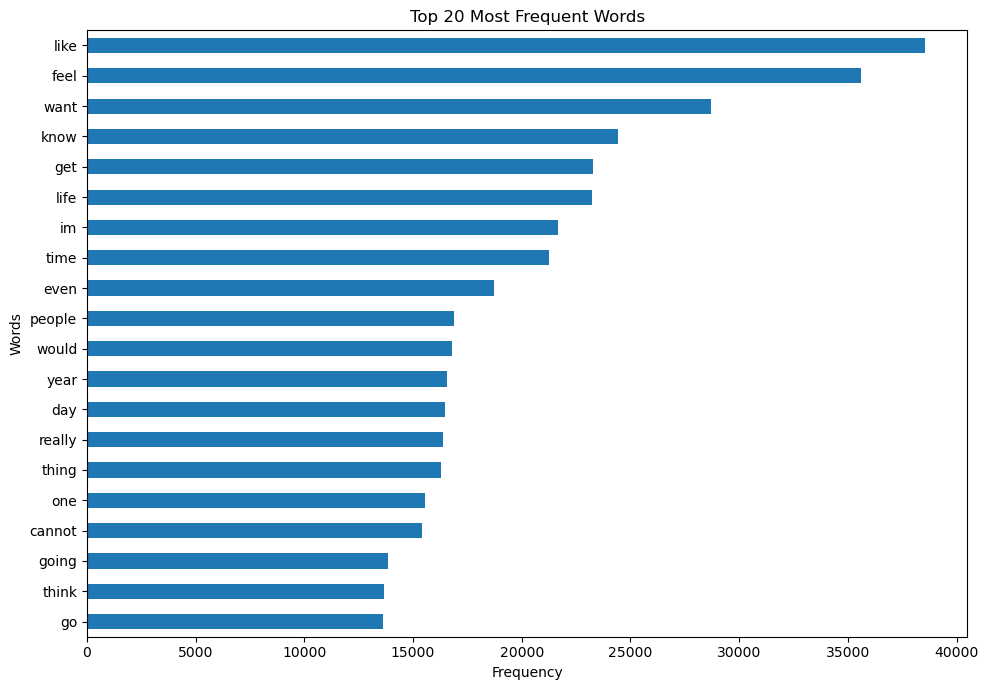

In [23]:
# Visualize the 20 most frequent words

top_words = word_frequency.head(20).sort_values()

plt.figure(figsize=(10, 7))

top_words.plot(kind="barh")

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.tight_layout()
plt.show()

In [24]:
# Import TF-IDF vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

print("TF-IDF library imported successfully!")

TF-IDF library imported successfully!


In [25]:
# Create TF-IDF features

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X = tfidf.fit_transform(df["cleaned_statement"])

print("TF-IDF transformation completed!")
print("Number of documents:", X.shape[0])
print("Number of features:", X.shape[1])

TF-IDF transformation completed!
Number of documents: 52681
Number of features: 10000


In [26]:
# Target variable

y = df["status"]

print("Target variable created!")
print("Number of classes:", y.nunique())
print("Classes:", y.unique())

Target variable created!
Number of classes: 7
Classes: ['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar'
 'Personality disorder']


In [27]:
from sklearn.model_selection import train_test_split

print("Train-test split library imported successfully!")

Train-test split library imported successfully!


In [28]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data split successfully!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Data split successfully!
Training samples: 42144
Testing samples: 10537


In [29]:
# Check class distribution after splitting

print("Training class distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training class distribution:
status
Normal                  31.02
Depression              29.24
Suicidal                20.22
Anxiety                  7.29
Bipolar                  5.27
Stress                   4.91
Personality disorder     2.05
Name: proportion, dtype: float64

Testing class distribution:
status
Normal                  31.02
Depression              29.24
Suicidal                20.22
Anxiety                  7.29
Bipolar                  5.28
Stress                   4.91
Personality disorder     2.04
Name: proportion, dtype: float64


In [30]:
# Import Logistic Regression

from sklearn.linear_model import LogisticRegression

print("Logistic Regression imported successfully!")

Logistic Regression imported successfully!


In [31]:
# Train Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [32]:
# Make predictions on the test data

y_pred = logistic_model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 10537


In [33]:
# Model evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.7646
Precision: 0.7726
Recall   : 0.7646
F1-Score : 0.7647


In [34]:
# Detailed classification report

print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

             Anxiety       0.79      0.81      0.80       768
             Bipolar       0.77      0.83      0.80       556
          Depression       0.79      0.63      0.70      3081
              Normal       0.88      0.91      0.90      3269
Personality disorder       0.52      0.75      0.61       215
              Stress       0.53      0.68      0.59       517
            Suicidal       0.65      0.72      0.68      2131

            accuracy                           0.76     10537
           macro avg       0.70      0.76      0.73     10537
        weighted avg       0.77      0.76      0.76     10537



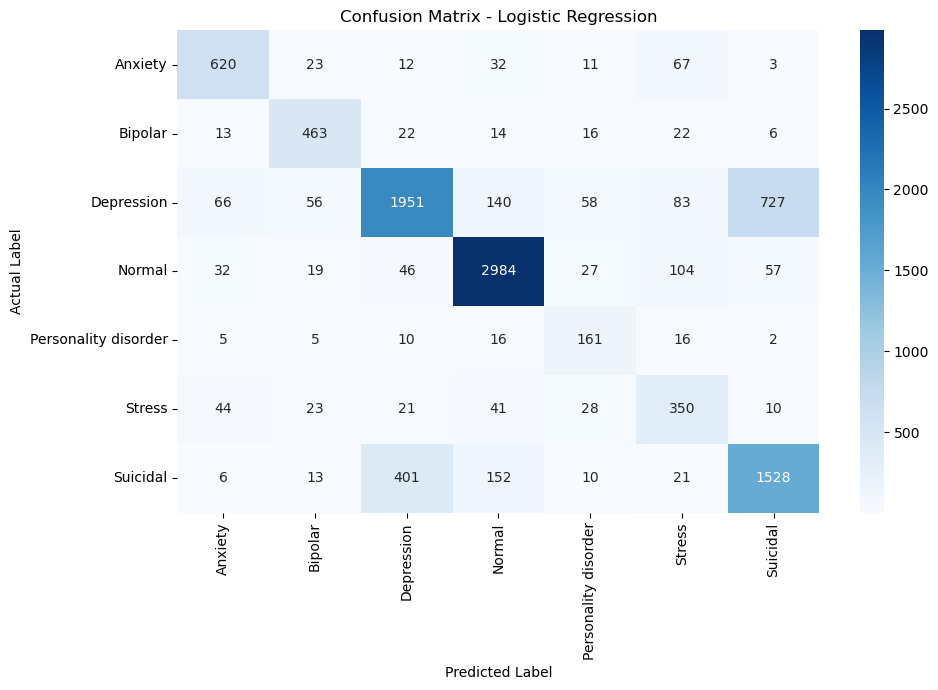

In [35]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=logistic_model.classes_)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=logistic_model.classes_,
    yticklabels=logistic_model.classes_
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [36]:
# Import Linear SVM

from sklearn.svm import LinearSVC

print("Linear SVM imported successfully!")

Linear SVM imported successfully!


In [37]:
# Train Linear SVM model

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train, y_train)

print("Linear SVM model trained successfully!")

Linear SVM model trained successfully!


In [38]:
# Make predictions using Linear SVM

svm_pred = svm_model.predict(X_test)

print("Linear SVM predictions generated successfully!")
print("Number of predictions:", len(svm_pred))

Linear SVM predictions generated successfully!
Number of predictions: 10537


In [39]:
# Evaluate Linear SVM

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, average="weighted")
svm_recall = recall_score(y_test, svm_pred, average="weighted")
svm_f1 = f1_score(y_test, svm_pred, average="weighted")

print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1-Score : {svm_f1:.4f}")

Accuracy : 0.7526
Precision: 0.7504
Recall   : 0.7526
F1-Score : 0.7500


In [40]:
# Detailed classification report for Linear SVM

print(classification_report(y_test, svm_pred))

                      precision    recall  f1-score   support

             Anxiety       0.77      0.81      0.79       768
             Bipolar       0.76      0.81      0.79       556
          Depression       0.74      0.64      0.69      3081
              Normal       0.87      0.93      0.90      3269
Personality disorder       0.63      0.68      0.65       215
              Stress       0.55      0.58      0.56       517
            Suicidal       0.64      0.65      0.65      2131

            accuracy                           0.75     10537
           macro avg       0.71      0.73      0.72     10537
        weighted avg       0.75      0.75      0.75     10537



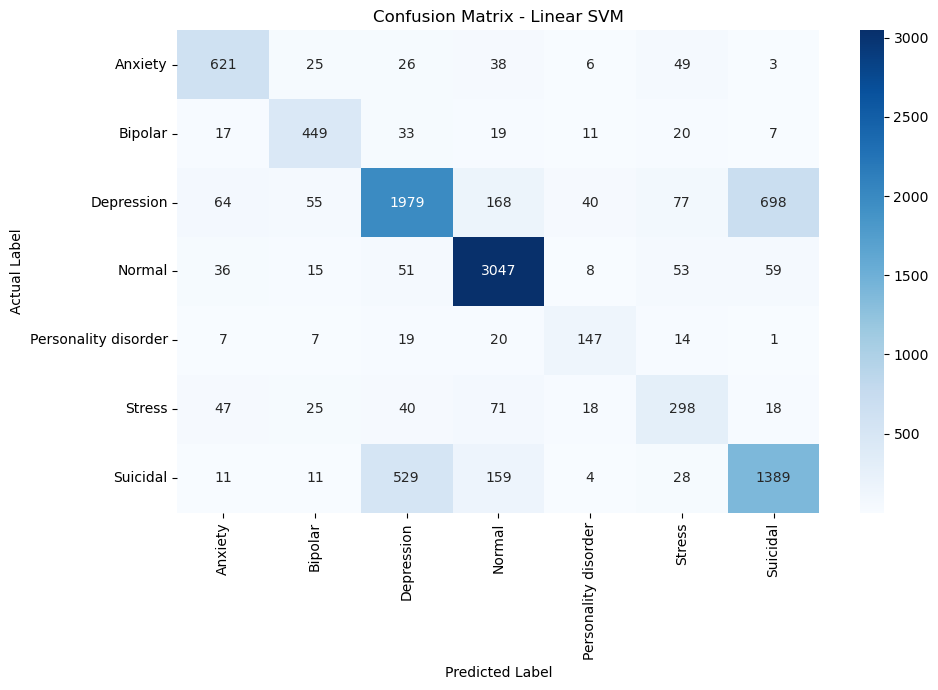

In [41]:
# Confusion Matrix - Linear SVM

svm_cm = confusion_matrix(
    y_test,
    svm_pred,
    labels=svm_model.classes_
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [42]:
# Compare Logistic Regression and Linear SVM

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy,
        svm_accuracy
    ],
    "Precision": [
        precision,
        svm_precision
    ],
    "Recall": [
        recall,
        svm_recall
    ],
    "F1-Score": [
        f1,
        svm_f1
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7646,0.7726,0.7646,0.7647
1,Linear SVM,0.7526,0.7504,0.7526,0.7500


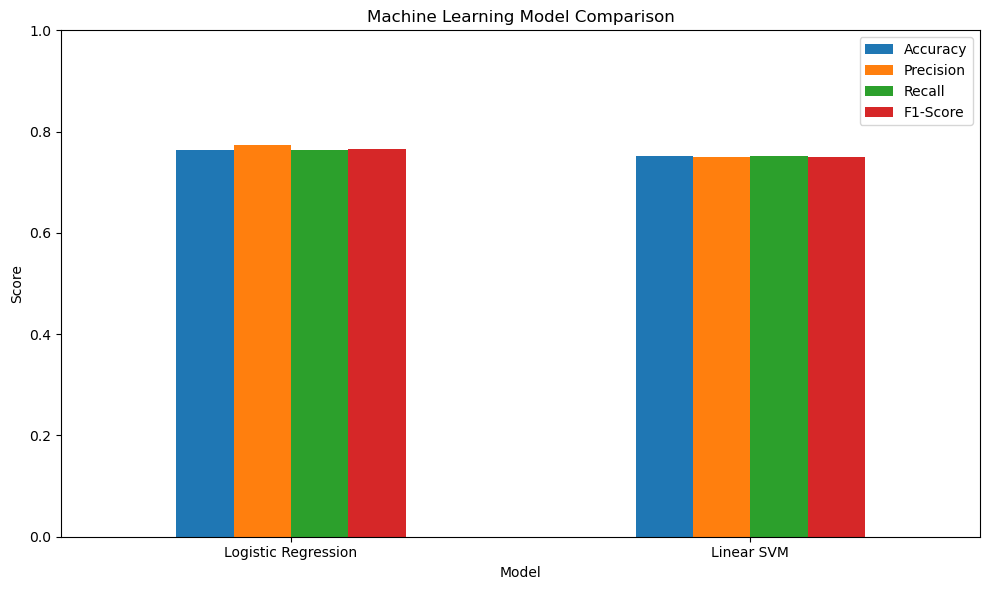

In [43]:
# Visualize model performance

comparison_plot = model_comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [44]:
# Get the TF-IDF feature names

feature_names = np.array(tfidf.get_feature_names_out())

print("Total TF-IDF features:", len(feature_names))

Total TF-IDF features: 10000


In [45]:
# Get the most important words for each category
# using Logistic Regression coefficients

for i, category in enumerate(logistic_model.classes_):
    
    top_indices = logistic_model.coef_[i].argsort()[-10:][::-1]
    
    top_words = feature_names[top_indices]
    
    print(f"\nTop words for {category}:")
    print(", ".join(top_words))


Top words for Anxiety:
anxiety, restless, anxious, worried, nervous, worry, cancer, im, restlessness, heart

Top words for Bipolar:
bipolar, manic, episode, med, mania, bp, hypomanic, im, lamictal, lithium

Top words for Depression:
depression, wa, depressed, cannot, ha, doe, anymore, antidepressant, pression, life

Top words for Normal:
wa, url, yes, ha, eid, twitter, met, ptsd, raya, com

Top words for Personality disorder:
avpd, avoidant, dont, people, social, im, poll, view poll, shame, interaction

Top words for Stress:
stress, tldr, stressed, ptsd, im, abuse, ive, dont know, flashback, anxiety

Top words for Suicidal:
cannot, suicide, suicidal, kill, die, anymore, rt, want, end, goodbye


In [46]:
# ==========================================
# FINAL CLEAN DATASET FOR SQL ANALYSIS
# ==========================================

# Select useful columns for the next stage
sql_df = df[
    [
        "statement",
        "cleaned_statement",
        "status",
        "character_count",
        "word_count",
        "sentence_count"
    ]
].copy()

# Save cleaned dataset
sql_df.to_csv(
    "Sentiment_Analysis_Cleaned.csv",
    index=False
)

print("Cleaned dataset exported successfully!")
print("Rows:", sql_df.shape[0])
print("Columns:", sql_df.shape[1])
print("File: Sentiment_Analysis_Cleaned.csv")

Cleaned dataset exported successfully!
Rows: 52681
Columns: 6
File: Sentiment_Analysis_Cleaned.csv


In [47]:
# Verify the exported dataset

check_df = pd.read_csv("Sentiment_Analysis_Cleaned.csv")

print("Export verification successful!")
print(check_df.shape)

check_df.head()

Export verification successful!
(52681, 6)


,statement,cleaned_statement,status,character_count,word_count,sentence_count
0,oh my gosh,oh gosh,Anxiety,10,3,1
1,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...,Anxiety,64,10,2
2,"All wrong, back off dear, forward doubt. Stay ...",wrong back dear forward doubt stay restless re...,Anxiety,78,14,2
3,I've shifted my focus to something else but I'...,ive shifted focus something else im still worried,Anxiety,61,11,1
4,"I'm restless and restless, it's been a month n...",im restless restless month boy mean,Anxiety,72,14,3


In [48]:
import os

print(os.path.abspath("Sentiment_Analysis_Cleaned.csv"))

C:\Users\HP\desktop\Data_Analyst_project\Sentiment_Analysis_Project\Sentiment_Analysis_Cleaned.csv


In [49]:
# Upload cleaned dataset to SQL Server

from sqlalchemy import create_engine
import urllib

server = r"HIMANSHU\SQLEXPRESS"
database = "SentimentAnalysisDB"
driver = "ODBC Driver 18 for SQL Server"

connection_string = (
    f"DRIVER={{{driver}}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
    f"TrustServerCertificate=yes;"
)

params = urllib.parse.quote_plus(connection_string)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}"
)

print("SQL Server connection created successfully!")

SQL Server connection created successfully!


In [50]:
# Upload cleaned dataset to SQL Server

sql_df.to_sql(
    "SentimentData",
    con=engine,
    if_exists="append",
    index=False,
    chunksize=1000
)

print("Data uploaded successfully to SQL Server!")
print("Records uploaded:", len(sql_df))

Data uploaded successfully to SQL Server!
Records uploaded: 52681
